# Introduction

My primary research question is: do time-varying acoustic features of narrative audio, including sound energy, spectral structure, and pitch, predict patterns of brain activity during naturalistic story listening? Furthermore, are these neural responses to acoustic features different during segments containing just speech, just music, or both speech and music? I plan on analyzing the “The Tunnel Under The World” from the Narratives Dataset (Nastase 2021). and extracting acoustic features using analysis libraries such as librosa. It includes functions to select sound energy, spectral features such as spectral centroid and Mel-Frequency Cepstral Coefficients (MFCCs), pitches, and spectral flux as time series that I can align to the audio timeline (with appropriate fMRI hemodynamic offset). I also plan on manually tagging the audio into three categories: speech-only, music-only, and speech + music, which can be used as grouping variables. I will then run classification, covariance, and ISC analyses as we have done in labs to evaluate the neural encoding sensitivities and identify regions of the brain where activity is best explained by the acoustic features.

## Table Of Contents
1. Introduction
2. [Setup](setup)
    1. [Load Audio](#loadaudio)
    2. [Extract Sonic Features](#extractsonic)
    3. [fMRI Preprocessing](#preprocessing)
    4. [Tagging](#tagging)
3. [Initial Testing](#testing)
    1. Encoding
    2. STRF Mapping
4. Classification
5. ISC
6. Hemispheric Assymetry
7. Discussion

# 2. Setup <a id="setup"></a>

Below, we import all the necessary libraries for the notebook and set up paths to directories that we will pull data from.

In [57]:
# Template from ECE480 Notebooks
import warnings
import sys

if not sys.warnoptions:
    warnings.simplefilter("ignore")
import os
import json
import glob
import numpy as np
import pandas as pd

from nilearn import datasets
from nilearn import plotting
from nilearn.input_data import NiftiMasker, NiftiLabelsMasker
from nilearn.glm.first_level import glover_hrf
import nibabel as nib

from brainiak import image, io
from brainiak.isc import isc, isfc, permutation_isc

from scipy.signal import convolve, find_peaks
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import librosa
import librosa.display

from inaSpeechSegmenter import Segmenter

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="white", context="notebook", font_scale=1, rc={"lines.linewidth": 2})

In [2]:
# Setup metadata for loading files
bids_dir = "/home/NEU480/datasets/narratives"
stimulus_dir = os.path.join(bids_dir, "stimuli")
transcripts_dir = os.path.join(stimulus_dir, "transcripts")
whisper_dir = os.path.join(stimulus_dir, "whisperx")
gentle_dir = os.path.join(stimulus_dir, "gentle/tunnel")
derivatives_dir = os.path.join(bids_dir, "derivatives")
mask_dir = os.path.join(derivatives_dir, "fmriprep")
data_dir = os.path.join(derivatives_dir, "afni-nosmooth")
audio_path = os.path.join(stimulus_dir, "tunnel_audio.wav")
dir_nilearn = "/home/NEU480/datasets/nilearn_data"

# Results path: Where the results and intermediate analyses of the tutorials are stored.
# Change this path only if you wish to save your outputs to a different folder.
scratch_directory = os.path.expanduser("/tmp/")
results_path = os.path.join(scratch_directory, "final_project_results")

# Set the location to store the data.
dir_out = f"{results_path}/"
if not os.path.exists(dir_out):
    os.makedirs(dir_out)
    print(f"Dir {dir_out} created.")
else:
    print(f"Dir {dir_out} exists.")

Dir /tmp/final_project_results/ created.


## 2A. Load Audio <a id="loadaudio"></a>

We use the `librosa` library to load the Tunnels Under the World audio. It decodes the file and returns a time-series of floats (using the default sampling rate of 22.05 Hz). This usually does not take too long.

In [3]:
import time

start_time = time.perf_counter()

# Load audio (sr=None preserves native sampling rate, or set to 22050 (22.05 Hz) for standard processing)
y, sr = librosa.load(audio_path)

end_time = time.perf_counter()

print(f"Loaded {audio_path}")
print(f"Duration: {librosa.get_duration(y=y, sr=sr):.2f} seconds")
print(f"Native SR: {sr}")
print(f"Time to load: {end_time - start_time:.2f} seconds")

Loaded /home/NEU480/datasets/narratives/stimuli/tunnel_audio.wav
Duration: 1533.77 seconds
Native SR: 22050
Time to load: 2.54 seconds


## 2B. Extract Sonic Features <a id="extractsonic"></a>

We begin by extracting **sound energy root mean squared** and **spectral flux**. The former measures the effective amplitude of the sound signal, i.e. its power or loudness, by calculating the root of the mean of adjacent instantaneous values, squared. The latter detects how quickly a signal's power spectrum changes over time, thereby capturing when sounds are onset and with what strength. 

In [6]:
# Sound Energy (root mean squared)
rms = librosa.feature.rms(y=y)[0]

# Spectral Flux
spectral_flux = librosa.onset.onset_strength(y=y, sr=sr)

# Create timestamps for each frame
frames = range(len(rms))
t = librosa.frames_to_time(frames, sr=sr)

# Create a dataframe for these features
energy_df = pd.DataFrame({
    'time': t,
    'rms_energy': rms,
    'spectral_flux': spectral_flux
})

In [7]:
energy_df.head(10)

,time,rms_energy,spectral_flux
0,0.00000,0.001695,0.000000
1,0.02322,0.001705,0.000000
2,0.04644,0.001722,0.000000
3,0.06966,0.001150,0.121475
4,0.09288,0.021806,0.017866
5,0.11610,0.054559,0.130707
6,0.13932,0.067246,4.359818
7,0.16254,0.087558,9.529262
8,0.18576,0.114422,4.745287
9,0.20898,0.137655,1.467012


Some other features we are looking at include **spectral centroids** and **Mel-Frequency Cepstral Coefficients (MFCCs)**, which inform our understanding of the audio's spectral structure. The centroids, per their name, indicate where most of the sound's energy is concentrated within its spectrum and measures the perceived "brightness" or "timbre" of the sound. MFCCs attempt to mimic how ears perceive sound (and therefore how the cortical region integrates diverse sonic structures) across 13 variables, where the first captures sonic energy, 2-4 the broad shape of the spectrum, and 5-13 various finer details from harmonies to consonants.

In [8]:
# Spectral Centroid
spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

# MFCCs (13 coefficients is standard)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

# Add to a spectral dataframe
spectral_cols = {f'mfcc_{i+1}': mfccs[i] for i in range(13)}
spectral_cols['spectral_centroid'] = spectral_centroid
spectral_df = pd.DataFrame(spectral_cols)
spectral_df['time'] = t

Lastly, we also extract **pitch**, important for both speech and music. We take the fundamental frequency from the audio, which will be used later for aligning with neural data from regions that may selectively respond to pitch.

<div class="alert alert-warning">Note: This steps tends to take ~10 minutes to complete.</div>

In [9]:
# Fundamental Frequency (F0) using probabilistic yin
begin_time = time.perf_counter()

f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=librosa.note_to_hz('C2'), 
                                            fmax=librosa.note_to_hz('C7'))
end_time = time.perf_counter()
print(f"Time to load: {end_time - start_time:.2f} seconds")

# Replace NaNs (silent segments) with 0 for the time series
f0_cleaned = np.nan_to_num(f0)

pitch_df = pd.DataFrame({
    'time': t,
    'fundamental_frequency': f0_cleaned
})

Time to load: 887.50 seconds


Now, we combine and time-align everything by converting from real time to TRs, using the dataset-proposed TR of 1.5. For the potentially multiple frames that fall within a single TR, we take their mean. 

In [10]:
TR = 1.5  

# Combine all features
all_features = pd.concat([energy_df, spectral_df.drop(columns='time'), pitch_df.drop(columns='time')], axis=1)

# Resample to match TR
all_features['tr_index'] = (all_features['time'] / TR).astype(int)
binned_features = all_features.groupby('tr_index').mean().reset_index()

Before we begin neural alignment, we want to redefine the sound energy column. The human ear perceives loudness logarithmically, so we will convert the linear RMS energy into a decibel (dB) scale to better represent auditory perception. To avoid log(0) issues when there's pure silence, we add a miniscule constant.

In [11]:
# Convert to decibels
binned_features['rms_energy_db'] = 20 * np.log10(binned_features['rms_energy'] + 1e-6)

# Drop the original linear RMS energy to avoid redundant features in the model
binned_features = binned_features.drop(columns=['rms_energy'])

## 2C. fMRI Preprocessing <a id="preprocessing"></a>

While brain data preprocessing steps have already been taken, such as motion correction, scanner noise, etc., we still have to convolve our audio data to the brain. Specifically, whereas `librosa` notes a potential peak in sound energy instantaneously, the BOLD fMRI signal peaks ~5-6 seconds after that same peak. Therefore, we need to convolve the sonic features with a hemodynamic response function that simulates the brain's delay, which allows us to properly compare the two.

In [19]:
# Generate the HRF kernel for our TR
hrf_kernel = glover_hrf(t_r=TR, oversampling=1)

# List of columns to convolve (everything except the TR index/time tracking columns)
features_to_convolve = [col for col in binned_features.columns if col not in ['tr_index', 'time']]

# Create a DataFrame to hold the convolved features
convolved_features = binned_features.copy()

for feature in features_to_convolve:
    # Convolve the feature with the HRF
    convolved_signal = convolve(binned_features[feature].values, hrf_kernel, mode='full')
    
    # The convolution output is longer than the input, so slice to match the original number of TRs
    convolved_features[feature] = convolved_signal[:len(binned_features)]

We standardize our values using Z-scoring. Note that features like F0 (Hz) and Sound Energy (dB) have different scales, and later regression may unfairly weight features simply because of larger raw numerical values.

In [20]:
scaler = StandardScaler()

# Scale the convolved features
convolved_features[features_to_convolve] = scaler.fit_transform(convolved_features[features_to_convolve])

The last thing we want to do for alignment is to note the 23 seconds of silence after the stimulus where the scanner kept running. Since that is present in the brain data, making up a total of 1040 TRs, we need to pad this dataframe with 17 TRs, since the audio was 1534 seconds long in comparison to the 1560 seconds of scanner runtime. 

In [30]:
TARGET_TRS = 1040
current_length = len(convolved_features)

if current_length < TARGET_TRS:
    end_padding_length = TARGET_TRS - current_length
    
    # Identify only the numerical feature columns
    feature_cols = [col for col in convolved_features.columns if col not in ['tr_index', 'time']]
    
    # Create 17 rows of zeros
    end_padding = pd.DataFrame(0, index=range(end_padding_length), columns=feature_cols)
    aligned_features = pd.concat([convolved_features, end_padding], ignore_index=True)

# Ensure the tr_index is correct for all 1040 rows
aligned_features['tr_index'] = range(TARGET_TRS)

## 2D. Tagging <a id="tagging"></a>
As our last step of preprocessing, we want to enable experimental analysis on our "speech" vs. "music" hypothesis. This means we have to tag the audio with TR-aligned labels that correctly represent speech, music, or both.

A hybrid approach will be used:
1. inaSpeechSegmenter - a convolutional neural network-based library that splits audio into speech, music, and noise. It outputs a table in the format (label, start, end), where the latter two fields are in seconds. However, this does not natively output a 'both speech & music' label. 
2. Gentle - a time-aligned transcript with word-level start and end labels, also in seconds. This can capture speech labeling.

So, a 'both speech & music' label can be created by overlapping the two outputs.

<div class="alert alert-warning">
Note: Segmenter() fails to run on Adroit because it does not come installed with its neural network weights to save space and attempts to download it from a URL. Since Adroit is offline, open a login node that has internet access and paste the following line to cache the weights in your home directory:

```python
python -c "from inaSpeechSegmenter import Segmenter; Segmenter()"
```
This also takes quite a while (~20 min) to run.

In [14]:
# Initialize the segmenter (this will download the pre-trained weights the first time)
seg = Segmenter()

# Run the segmentation on your audio file
begin_time = time.perf_counter()
audio_path = os.path.join(stimulus_dir, "tunnel_audio.wav")
segmentation = seg(audio_path)
end_time = time.perf_counter()
print(f"Time to load: {end_time - start_time:.2f} seconds")

# Convert to a DataFrame for easy viewing
seg_df = pd.DataFrame(segmentation, columns=['label', 'start', 'end'])
print(seg_df.head())

# Filter purely for the music tags
music_tags = seg_df[seg_df['label'] == 'music']
print(music_tags.head())

E0000 00:00:1778692617.795387   36040 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1997/1997 - 42s - 21ms/step
1596/1596 - 168s - 105ms/step
Time to load: 2401.99 seconds
      label  start    end
0      male   0.00   2.42
1  noEnergy   2.42   3.20
2      male   3.20   4.80
3  noEnergy   4.80   5.38
4     music   5.38  13.02
    label   start     end
4   music    5.38   13.02
29  music   66.82   78.54
43  music  121.92  124.94
45  music  134.10  135.58
86  music  209.00  215.34


Unfortunately, though inaSpeechSegmenter did a great job at detecting speech and music segments separately, it performed much worse at detecting when they occurred simultaneously. This is partly due to the Tunnel audio's format: long dialogue sections are punctured by short bursts of orchestral incidental music, which usually feature for 3-4 seconds before fading rapidly in volume and playing at a very low decibel as the narrator or a character starts talking. They usually only co-occur for a few seconds before the music fades out completely, so due to this constraint we chose to forgo analysis of the 'both speech and music' label. However, we still overlap the outputs of the two engines to create a comprehensive TR-by-TR capture of the speech and music of the audio. Combining the inaSpeechSegmenter with Gentle also helps to smear any noise either may have and validate the speech-music boundaries.

Gentle transcripts have a specific JSON format that we will parse now. Additionally, as the dataset metadata mentioned 126 unsuccessfully localized words, this will also show in the transcript, specifically in the `case` field as `not-found-in-audio`. Looping through every word looking for the `start` and `end` fields will throw a key error for those words, so we begin by filtering them out.

In [15]:
# Load Gentle JSON file
gentle_filepath = os.path.join(gentle_dir, "align.json")
with open(gentle_filepath, 'r') as f:
    gentle_data = json.load(f)

# Extract and filter words, 'success' only
valid_speech_words = [
    word for word in gentle_data['words'] 
    if word.get('case') == 'success' and 'start' in word and 'end' in word
]

print(f"Total words: {len(gentle_data['words'])}")
print(f"Successfully aligned speech blocks: {len(valid_speech_words)}")

Total words: 3435
Successfully aligned speech blocks: 3309


Now we can align the inaSpeechSegmenter data with the Gentle transcript.

In [31]:
# Initialize our array
tr_labels = np.full(TARGET_TRS, "silence", dtype=object)

# Loop through all TRs to check for speech or music
for i in range(TARGET_TRS):
    tr_audio_start = i * TR
    tr_audio_end = tr_audio_start + TR
    
    is_speech = False
    is_music = False
    
    # Check Gentle for speech, only if any word falls in this TR
    for word in valid_speech_words:
        if word['start'] < tr_audio_end and word['end'] > tr_audio_start:
            is_speech = True
            break
            
    # Check inaSpeechSegmenter for music
    for _, row in music_tags.iterrows():
        if row['label'] == 'music':
            if row['start'] < tr_audio_end and row['end'] > tr_audio_start:
                is_music = True
                break
                
    # Assign the categorical tag
    if is_speech and is_music:
        tr_labels[i] = "speech_music"
    elif is_speech:
        tr_labels[i] = "speech"
    elif is_music:
        tr_labels[i] = "music"

# Add it to the feature matrix
aligned_features['category'] = tr_labels

# Create binary indicator columns, later used for regression
category_dummies = pd.get_dummies(aligned_features['category'], prefix='is')
aligned_features = pd.concat([aligned_features, category_dummies], axis=1)

print("Tagging complete. Final matrix shape:", aligned_features.shape)
print(aligned_features[['tr_index', 'category', 'is_speech', 'is_music', 'is_speech_music']].head(5))

Tagging complete. Final matrix shape: (1040, 24)
   tr_index category  is_speech  is_music  is_speech_music
0         0   speech       True     False            False
1         1   speech       True     False            False
2         2   speech       True     False            False
3         3    music      False      True            False
4         4    music      False      True            False


# 3. Initial Testing <a id="testing"></a>

We can finally begin our running analyses. We start with some basic visualizations to see the sonic structure of the Tunnel audio. Note that MFCCs are dimensionless numerical values.

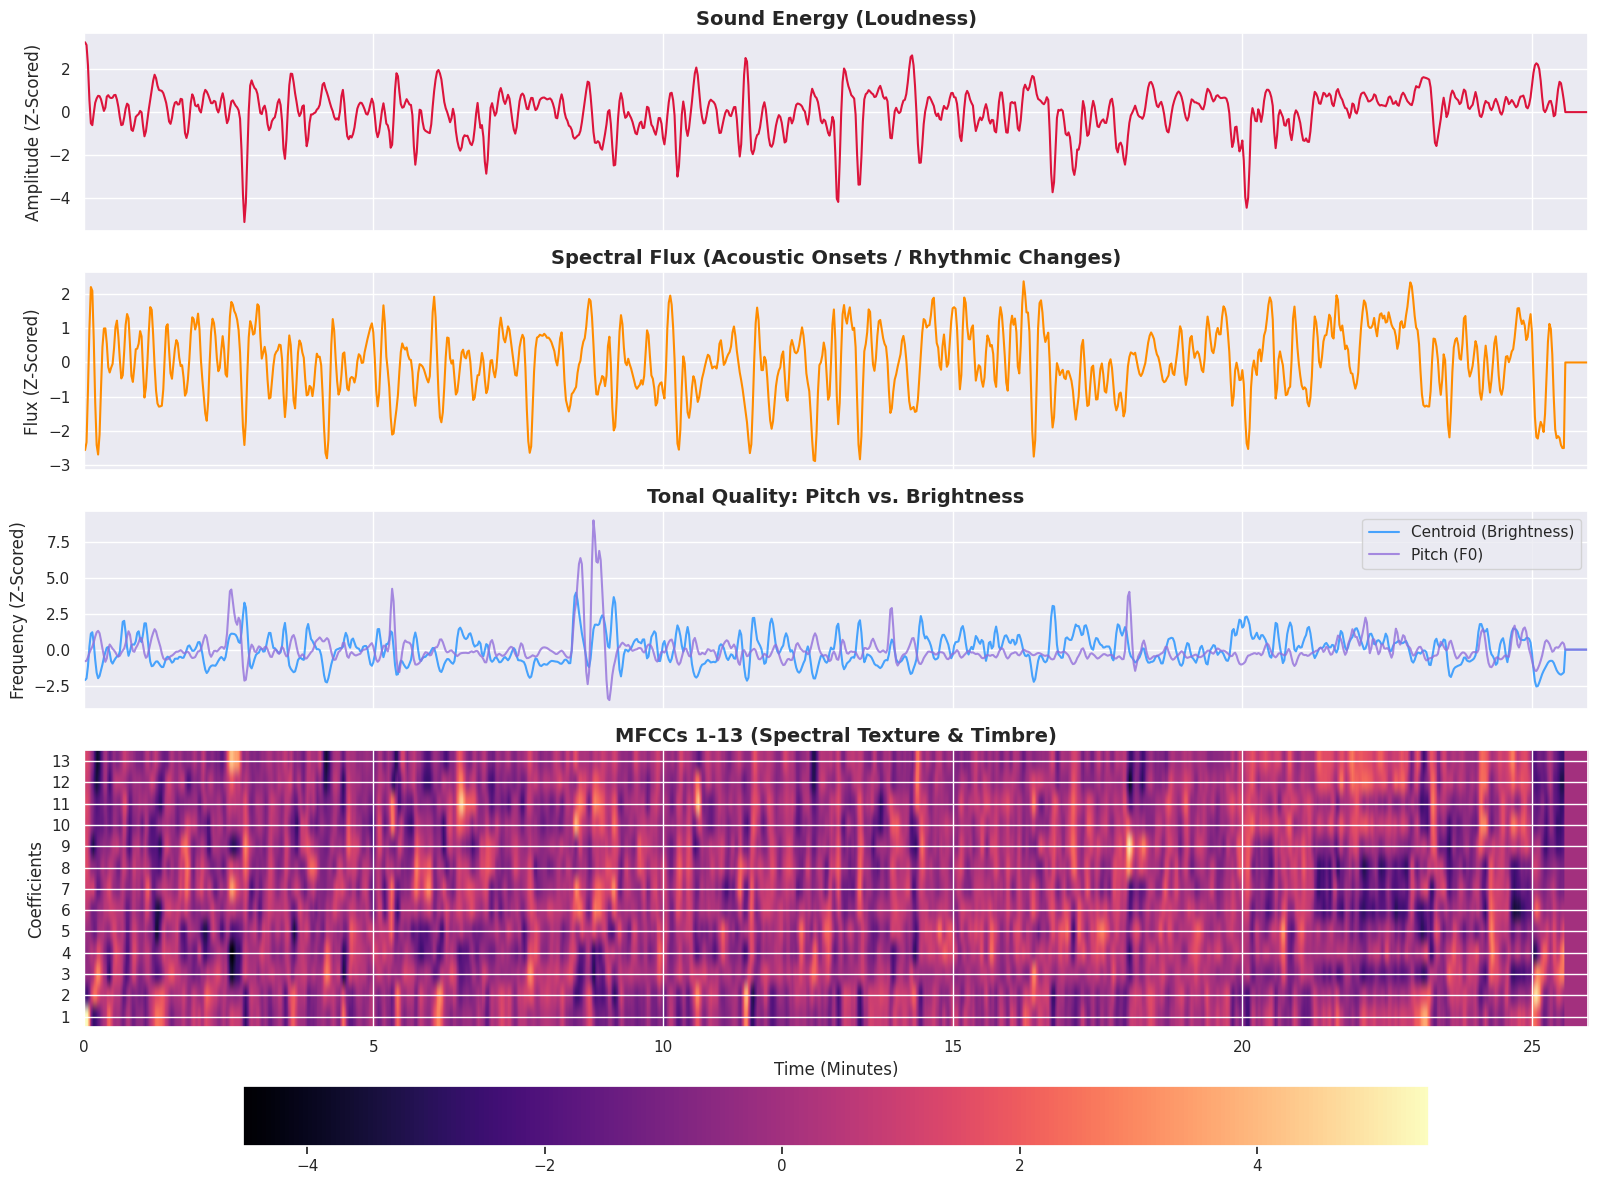

In [33]:
# Convert TR index to minutes for a cleaner x-axis
time_in_minutes = (aligned_features['tr_index'] * TR) / 60

# Set up plot
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1, 2]})
sns.set_theme(style="darkgrid")

# Plot 1: Sound Energy
axes[0].plot(time_in_minutes, aligned_features['rms_energy_db'], color='crimson', linewidth=1.5)
axes[0].set_title('Sound Energy (Loudness)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude (Z-Scored)')

# Plot 2: Spectral Flux (Onsets)
axes[1].plot(time_in_minutes, aligned_features['spectral_flux'], color='darkorange', linewidth=1.5)
axes[1].set_title('Spectral Flux (Acoustic Onsets / Rhythmic Changes)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Flux (Z-Scored)')

# Plot 3: Pitch & Spectral Centroid
axes[2].plot(time_in_minutes, aligned_features['spectral_centroid'], color='dodgerblue', label='Centroid (Brightness)', alpha=0.8)
axes[2].plot(time_in_minutes, aligned_features['fundamental_frequency'], color='mediumpurple', label='Pitch (F0)', alpha=0.8)
axes[2].set_title('Tonal Quality: Pitch vs. Brightness', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Frequency (Z-Scored)')
axes[2].legend(loc='upper right')

# Plot 4: MFCC Heatmap (Timbre)
# Extract the MFCC columns and transpose them for the heatmap (Features on Y, Time on X)
mfcc_cols = [f'mfcc_{i}' for i in range(1, 14)]
mfcc_data = aligned_features[mfcc_cols].T

# Get the max time to bind the image to the correct axis scale
max_time = time_in_minutes.max()

im = axes[3].imshow(mfcc_data, aspect='auto', cmap='magma', origin='lower',
                    extent=[0, max_time, 0, 13])
axes[3].set_title('MFCCs 1-13 (Spectral Texture & Timbre)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Coefficients')
axes[3].set_xlabel('Time (Minutes)', fontsize=12)

# Set the y-ticks to match the 13 coefficients
axes[3].set_yticks(np.arange(0.5, 13.5, 1))
axes[3].set_yticklabels(range(1, 14))

# Bind a colorbar to this axis
fig.colorbar(im, ax=axes[3], orientation='horizontal')

plt.tight_layout()
plt.show()

## 3A. Encoding <a id="encoding"></a>

Let's try aligning these features to the brain. We will focus primarily on the auditory cortex in the superior temporal lobe (Heschl's Gyrus) and the superior temporal gyrus. To get the BOLD signals for these specific ROIs, we align the brain to the Harvard-Oxford cortical atlas and extract those patches. For now, let's work with just one subject to confirm some preliminary results to assure us of how we parsed the audio data.

In [34]:
# Fetch the Harvard-Oxford cortical atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm', data_dir=dir_nilearn)
atlas_filename = atlas.maps
labels = atlas.labels

# Find the indices for our target Auditory ROIs
heschls_idx = labels.index("Heschl's Gyrus (includes H1 and H2)")
stg_anterior_idx = labels.index("Superior Temporal Gyrus, anterior division")
stg_posterior_idx = labels.index("Superior Temporal Gyrus, posterior division")

print(f"Heschl's Gyrus index: {heschls_idx}")
print(f"STG Anterior index: {stg_anterior_idx}")
print(f"STF Posterior index: {stg_posterior_idx}")

[fetch_atlas_harvard_oxford] Dataset found in /home/NEU480/datasets/nilearn_data/fsl

Heschl's Gyrus index: 45
STG Anterior index: 9
STF Posterior index: 10


In [35]:
# Choose subject
subj_id = "sub-005"
test_subject_filepath = os.path.join(data_dir, f"{subj_id}/func/{subj_id}_task-tunnel_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz")
print(f"Processing subject: {test_subject_filepath}")

# Setup masker
masker = NiftiLabelsMasker(labels_img=atlas_filename, labels=labels, t_r=TR)

# Extract the time series
time_series = masker.fit_transform(test_subject_filepath)
print(f"Extracted time series shape: {time_series.shape} (Expected: 1040 TRs, 48 Regions)")

Processing subject: /home/NEU480/datasets/narratives/derivatives/afni-nosmooth/sub-005/func/sub-005_task-tunnel_space-MNI152NLin2009cAsym_res-native_desc-clean_bold.nii.gz
Extracted time series shape: (1040, 48) (Expected: 1040 TRs, 48 Regions)


In [36]:
# The masker drops the 'Background' label (index 0), so we must shift our label indices by -1
heschls_signal = time_series[:, heschls_idx - 1]
stg_ant_signal = time_series[:, stg_anterior_idx - 1]
stg_post_signal = time_series[:, stg_posterior_idx - 1]

# For later, we construct a composite time series that averages the above three ROIs
auditory_signal = np.mean([heschls_signal, stg_ant_signal, stg_post_signal], axis=0)

Our first experiment is to correlate sound energy with BOLD activity. Schmalzle et. al. (2022) found that in naturalistic audio listening, temporal changes in sound energy predicted moments of heightened attention and synchonicity. While we explore synchronicity later using ISC, we test here if there is indeed a positive correlation between energy and brain activity.

Correlation (r): 0.3881
P-value (p): 9.9751e-39


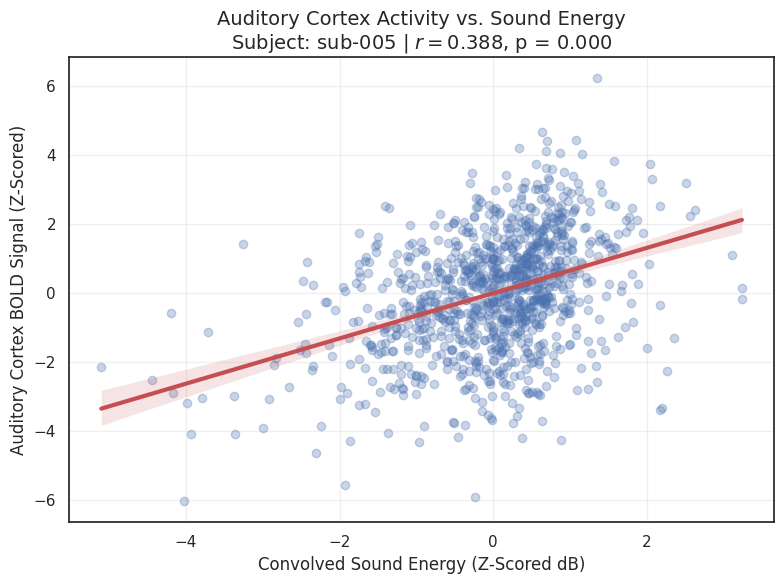

In [38]:
sound_energy = aligned_features['rms_energy_db'].values

# Calculate Pearson correlation
r_value, p_value = pearsonr(sound_energy, heschls_signal)

print(f"Correlation (r): {r_value:.4f}")
print(f"P-value (p): {p_value:.4e}")

# Visualization: Scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(x=sound_energy, y=heschls_signal, scatter_kws={'alpha':0.3, 'color':'#4C72B0'}, line_kws={'color':'#C44E52'})
plt.title(f"Auditory Cortex Activity vs. Sound Energy\nSubject: {os.path.basename(test_subject_filepath)[:7]} | $r = {r_value:.3f}$, p = {p_value:.3f}", fontsize=14)
plt.xlabel("Convolved Sound Energy (Z-Scored dB)", fontsize=12)
plt.ylabel("Auditory Cortex BOLD Signal (Z-Scored)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This is a good result! With a r-value of 0.3881 and a significant p-value, we have shown that there is a strong relationship between sound energy and a partipant's brain activity in the auditory cortex. However, in another preliminary test I ran (not included in this notebook), I had to measure cross-correlation, i.e. the correlation between two signals if one was displaced relative to the other, and found the following results:

Base Correlation: r=0.3881, p=9.9751e-39


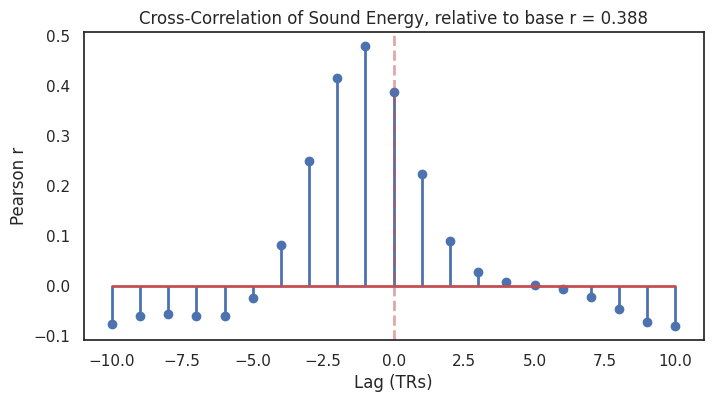

In [40]:
print(f"Base Correlation: r={r_value:.4f}, p={p_value:.4e}")

# Cross-Correlation (Lag Plot) to check alignment
lags = np.arange(-10, 11) # Check +/- 10 TRs (15 seconds)
cross_corr = [pearsonr(np.roll(sound_energy, lag), heschls_signal)[0] for lag in lags]

plt.figure(figsize=(8, 4))
plt.stem(lags, cross_corr)
plt.title(f"Cross-Correlation of Sound Energy, relative to base r = {r_value:.3f}")
plt.xlabel("Lag (TRs)")
plt.ylabel("Pearson r")
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.show()

While this does follow the general HRF basis function that we might expect to see, with decreasing correlation in either direction of the peak, it seems that the time alignment preset by the dataset may have been too much. In investigating this phenomenon, I came across Handwerker et. al. (2004), which found that hemodynamic responses varied across subjects and crucially, brain ROIs. Time-to-peak or time-to-onset had an observed 2.5 seconds window of misestimates. The general HRF convolution assumes an averaged response time for the entire brain, but with this differential HRF, it could be the reason why the auditory cortex's correlation seems to peak an entire TR earlier. To capture this important characteristic, we need to temporally shift everything 1 TR back.

In [43]:
# Only shift columns with acoustic data
cols_to_shift = [col for col in aligned_features.columns if col not in ['tr_index', 'time']]

# Shift data backwards by 1 TR
aligned_features[cols_to_shift] = aligned_features[cols_to_shift].shift(-1)

# Fill last row and any other NaNs with appropriate values
aligned_features['category'] = aligned_features['category'].fillna('silence')
numeric_cols = [col for col in cols_to_shift if col != 'category']
aligned_features[numeric_cols] = aligned_features[numeric_cols].fillna(0)

# Save matrix
final_aligned_path = os.path.join(dir_out, "FINAL_tunnel_feature_matrix_1040TR.csv")
aligned_features.to_csv(final_aligned_path, index=False)

print(f"Applied -1 TR physiological shift. Final shape: {aligned_features.shape}")

Applied -1 TR physiological shift. Final shape: (1040, 24)


With the correct temporal padding, let's try the previous sound energy vs. activity in Heschl's Gyrus again.

Corrected Correlation: r=0.4807, p=3.0273e-61


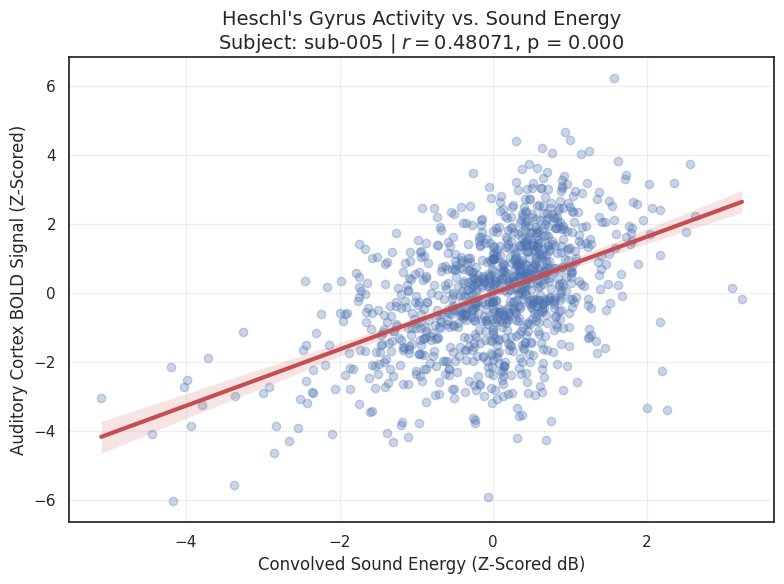

In [47]:
# Load from the corrected feature matrix
sound_energy = aligned_features['rms_energy_db'].values

# Calculate Pearson correlation
r_value, p_value = pearsonr(sound_energy, heschls_signal)

print(f"Corrected Correlation: r={r_value:.4f}, p={p_value:.4e}")

# Visualization: Scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(x=sound_energy, y=heschls_signal, scatter_kws={'alpha':0.3, 'color':'#4C72B0'}, line_kws={'color':'#C44E52'})
plt.title(f"Heschl's Gyrus Activity vs. Sound Energy\nSubject: {os.path.basename(test_subject_filepath)[:7]} | $r = {r_value:.5f}$, p = {p_value:.3f}", fontsize=14)
plt.xlabel("Convolved Sound Energy (Z-Scored dB)", fontsize=12)
plt.ylabel("Auditory Cortex BOLD Signal (Z-Scored)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Much better! Our correlation went from 0.3188 to 0.4807, a huge increase. We will use this correctly aligned data for the rest of the analyses, but this also shows why it is important to verify previous results. Though we did have a positive correlation, we expected a slightly stronger relationship, which we now have.

Now, let's do a similar analysis for spectral flux.

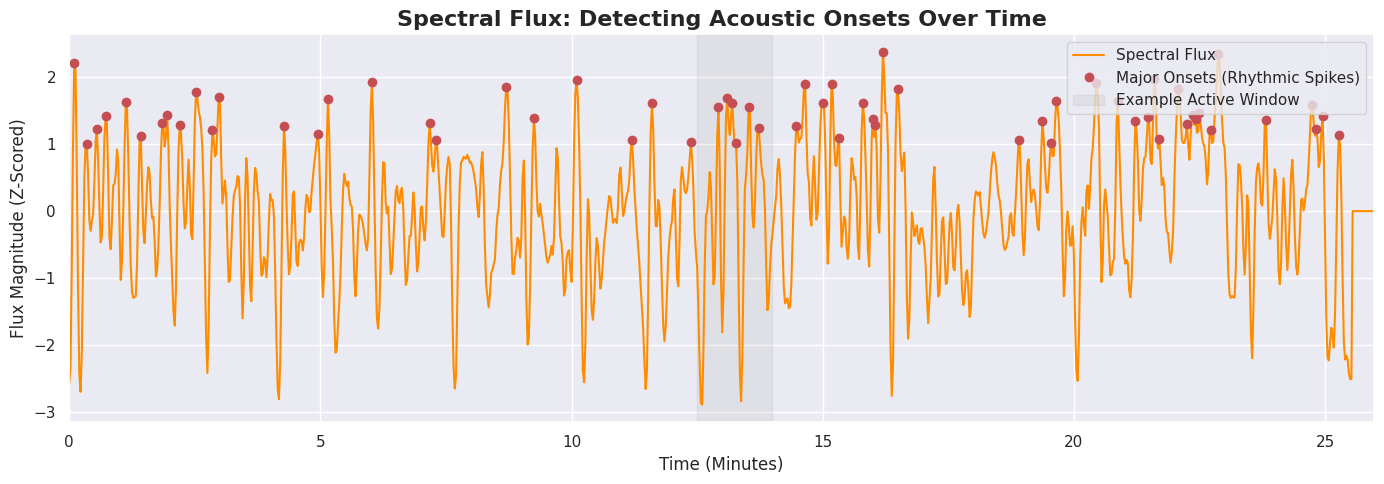

In [49]:
time_in_minutes = (aligned_features['tr_index'] * 1.5) / 60
flux_signal = aligned_features['spectral_flux'].values

# Find the peaks (onsets) in the flux signal
# height=1.0 as we only care about peaks that are at least 1 standard deviation above the mean
# distance=1.5 ensures we don't pick up multiple peaks within 1 TR of each other
peaks, properties = find_peaks(flux_signal, height=1.0, distance=TR)

# Set up plot
plt.figure(figsize=(14, 5))
sns.set_theme(style="darkgrid")

# Plot flux
plt.plot(time_in_minutes, flux_signal, color='darkorange', linewidth=1.5, label='Spectral Flux')

# Overlay the detected peaks as red dots
plt.plot(time_in_minutes[peaks], flux_signal[peaks], "ro", markersize=6, label='Major Onsets (Rhythmic Spikes)')

# Highlight a specific highly-active window
plt.axvspan(12.5, 14, color='gray', alpha=0.1, label='Example Active Window')

plt.title('Spectral Flux: Detecting Acoustic Onsets Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Time (Minutes)', fontsize=12)
plt.ylabel('Flux Magnitude (Z-Scored)', fontsize=12)
plt.legend(loc='upper right')
plt.xlim(0, time_in_minutes.max())
plt.tight_layout()
plt.show()

Overall A1 Correlation with Spectral Flux: r=0.4125, p=5.5105e-44


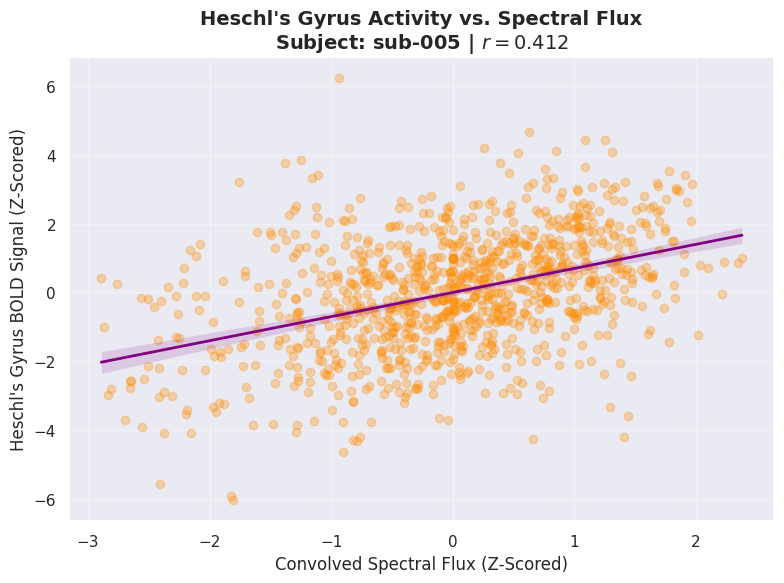

In [27]:
# 1. Extract the newly aligned Spectral Flux signal
flux_signal = aligned_features['spectral_flux'].values

# 2. Calculate the overall Pearson correlation
r_val_flux, p_val_flux = pearsonr(flux_signal, heschls_signal)

print(f"Overall A1 Correlation with Spectral Flux: r={r_val_flux:.4f}, p={p_val_flux:.4e}")

# 3. Visualization: Scatter plot with regression line
plt.figure(figsize=(8, 6))

# Using an orange/purple color scheme to differentiate from the Sound Energy plot
sns.regplot(x=flux_signal, y=heschls_signal, 
            scatter_kws={'alpha':0.3, 'color':'darkorange'}, 
            line_kws={'color':'purple', 'linewidth': 2})

plt.title(f"Heschl's Gyrus Activity vs. Spectral Flux\nSubject: {os.path.basename(test_subject_filepath)[:7]} | $r = {r_val_flux:.3f}$", fontsize=14, fontweight='bold')
plt.xlabel("Convolved Spectral Flux (Z-Scored)", fontsize=12)
plt.ylabel("Heschl's Gyrus BOLD Signal (Z-Scored)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

One final check we'll do is to run the sound energy analysis on a control ROI. Here, we pick the Occipital Fusiform Gyrus, a key area of the visual cortex but not of the auditory system, in theory. We expect that it should have very little correlation with sound energy.

Corrected A1 Correlation: r=-0.0014, p=9.6361e-01


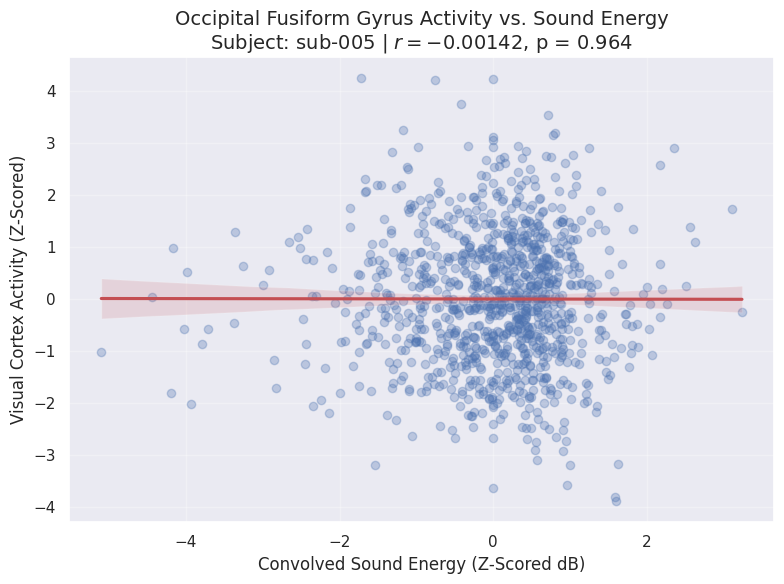

In [51]:
# CONTROL GROUP
control_idx = labels.index("Occipital Fusiform Gyrus")
control_signal = time_series[:, control_idx - 1]

# Calculate Pearson correlation with pure A1 signal
r_value, p_value = pearsonr(sound_energy, control_signal)

print(f"Corrected A1 Correlation: r={r_value:.4f}, p={p_value:.4e}")

# Visualization: Scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(x=sound_energy, y=control_signal, scatter_kws={'alpha':0.3, 'color':'#4C72B0'}, line_kws={'color':'#C44E52'})
plt.title(f"Occipital Fusiform Gyrus Activity vs. Sound Energy\nSubject: {os.path.basename(test_subject_filepath)[:7]} | $r = {r_value:.5f}$, p = {p_value:.3f}", fontsize=14)
plt.xlabel("Convolved Sound Energy (Z-Scored dB)", fontsize=12)
plt.ylabel("Visual Cortex Activity (Z-Scored)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Indeed, that's what we find! An almost horizontal line with r-value -0.00142 and p-value 0.964. With this initial confirmation of the validity of our audio parsing, we move on to novel analyses.

# 4. Classification <a id="classification"></a>

## 4A. Encoding Part 2

We want to see how well we can predict the brain's activity based on the continuous phyiscal properties of the sound. Since we expect quantities such as sound energy and spectral flux to rise and fall together, we use L2 regularization as they are highly correlated. We first split into training and testing splits with a 90/10 split, standardize the training features, then cross-validate to find the best performing penalty parameter before testing it on the held-out data.

In [60]:
# Extract acoustic features for X
acoustic_cols = ['rms_energy_db', 'spectral_flux', 'fundamental_frequency']
acoustic_cols.extend([f'mfcc_{i+1}' for i in range(13)])
X_encode = aligned_features[acoustic_cols].values

# Use Heschl's Gyrus signal for Y
Y_encode = heschls_signal 

# Split into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X_encode, Y_encode, test_size=0.1
)

# Standardize training features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train using cross-validation
alphas = np.logspace(-1, 3, 10) # test penalties from 0.1 to 1000
model = RidgeCV(alphas=alphas, cv=5)
model.fit(X_train, Y_train)

# Evaluate the Model
Y_pred = model.predict(X_test)
r2 = r2_score(Y_test, Y_pred)

print(f"Encoding Model R^2 Score: {r2:.4f}")
print(f"Best Alpha: {model.alpha_:.2f}")

Encoding Model R^2 Score: 0.3683
Best Alpha: 46.42


The model score is not bad, but to see which features are driving the primary auditory cortex activity the most, we plot them below and see which weights (betas) are largest.

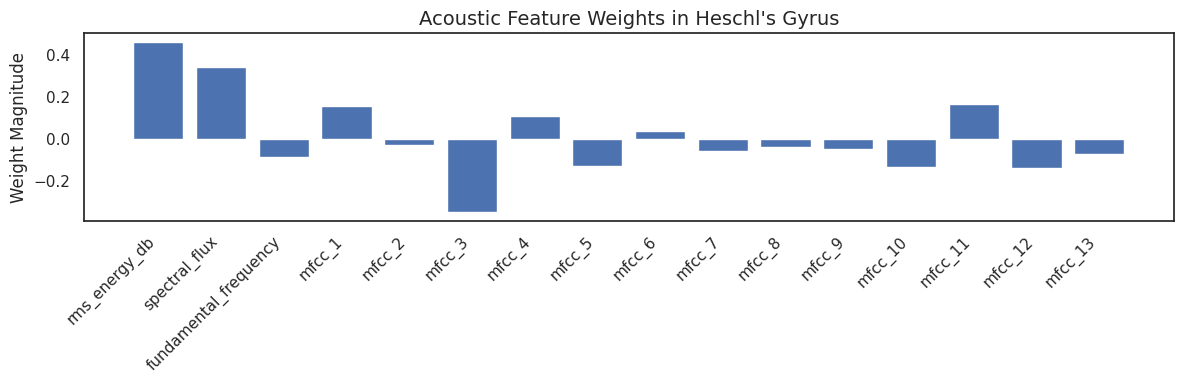

In [66]:
# Plot the the feature weights
plt.figure(figsize=(12, 4))
plt.bar(acoustic_cols, model.coef_, color='#4C72B0') 
plt.title("Acoustic Feature Weights in Heschl's Gyrus", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Weight Magnitude")
plt.tight_layout()
plt.show()

Unsurprisingly, sound energy and spectral flux seem to be the largest impact features, though it seems mfcc_3 also has a strong negative weight. MFCC3 generally captures mid-frequency peaks and valleys, typically associated with formant structures of human speech such as differentiating vowels. Since Heschl's gyrus does capture a lot of the finer details of human speech, this relationship makes sense.

In thinking about components such as fundamental frequency, we probably would not expect there to be a strong linear relationship between it and BOLD activity. That would imply that higher notes inspire higher activity overall, which intuitively does not make sense even as there may be brain regions that selectively respond to certain pitches.

# 4B. SVM Classification and Decoding

For this analysis, we want to go the other direction: given brain activity, can we decode the sound that the participant is listening to? To focus this question, we look at the category label: speech or music (or silence). Earlier, we added binary indicator columns to each TR that represented whether

# 5. DISCUSSION



# SCRIPT FOR SAVING FILES

In [67]:
# 1. Save the Final Feature Matrix
aligned_features.to_csv("FINAL_tunnel_feature_matrix_1040TR.csv", index=False)
print("Saved final feature matrix.")

# 2. Save the inaSpeechSegmenter Output
seg_df.to_csv("segmenter_music_tags_raw.csv", index=False)
print("Saved raw inaSpeechSegmenter tags.")

# 3. Save the Cleaned Gentle Speech Words
speech_df = pd.DataFrame(valid_speech_words)
# Drop the bulky phones column
if 'phones' in speech_df.columns:
    speech_df = speech_df.drop(columns=['phones'])
speech_df.to_csv("gentle_speech_tags_clean.csv", index=False)
print("Saved cleaned Gentle speech tags.")

Saved final feature matrix.
Saved raw inaSpeechSegmenter tags.
Saved cleaned Gentle speech tags.


MISC/FOR LATER:

In [ ]:
# SAFE FMRI LOADING, SUBJECT EXCLUSION
import glob

# Grab all subject files for the tunnel task
all_subjects = glob.glob(os.path.join(data_dir, "*task-tunnel*.nii.gz"))

# Exclude the flagged subjects
excluded_subjects = ['sub-004', 'sub-013']
valid_subjects = [sub for sub in all_subjects if not any(excl in sub for excl in excluded_subjects)]

print(f"Found {len(valid_subjects)} valid subjects for analysis.")

# References

Atencio, C. A., Sharpee, T. O., & Schreiner, C. E. (2012). Receptive field dimensionality increases from the auditory midbrain to cortex. Journal of neurophysiology, 107(10), 2594–2603. https://doi.org/10.1152/jn.01025.2011.

Bendor, D., & Wang, X. The neuronal representation of pitch in primate auditory cortex. Nature 436, 1161–1165 (2005). https://doi.org/10.1038/nature03867.

Handwerker, D. A., Ollinger, J. M., & D'Esposito, M. (2004). Variation of BOLD hemodynamic responses across subjects and brain regions and their effects on statistical analyses. NeuroImage, 21(4), 1639-1651.

Hudspeth, A. J., & Konishi, M. (2000). Auditory neuroscience: development, transduction, and integration. Proceedings of the National Academy of Sciences of the United States of America, 97(22), 11690–11691. https://doi.org/10.1073/pnas.97.22.11690.

Nastase, S. A., Liu, Y.-F., Hillman, H., Zadbood, A., Hasenfratz, L., Keshavarzian, N., Chen, J., Honey, C. J., Yeshurun, Y., Regev, M., Nguyen, M., Chang, C. H. C., Baldassano, C., Lositsky, O., Simony, E., Chow, M. A., Leong, Y. C., Brooks, P. P., Micciche, E., … Hasson, U. (2021). The “Narratives” fMRI dataset for evaluating models of naturalistic language comprehension. Scientific Data, 8(1), 250. https://doi.org/10.1038/s41597-021-01033-3

Schmalzle, R., Wilcox, S., Jahn, N. T.(2022). Identifying moments of peak audience engagement from brain responses during story listening. Communication Monographs, 89(4). https://www.tandfonline.com/doi/full/10.1080/03637751.2022.2032229#abstract.

Zatorre, R. J., Belin, P., & Penhune, V. B. (2002). Structure and function of auditory cortex: music and speech. Trends in cognitive sciences, 6(1), 37–46. https://doi.org/10.1016/s1364-6613(00)01816-7.
